In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [9]:
fake_df=pd.read_csv("Fake.csv")
true_df=pd.read_csv("True.csv")

fake_df["label"]=0
true_df["label"]=1

df=pd.concat([fake_df,true_df],axis=0)
df = df.sample(frac=1, random_state=42).reset_index(drop=True) # Shuffled 



In [10]:
print("Shape:",df.shape)
df.head()

Shape: (44898, 5)


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


In [12]:
df["content"] = df["title"] + " " + df["text"]
df = df[["content", "label"]]

df.head()


,content,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,0
1,Trump drops Steve Bannon from National Securit...,1
2,Puerto Rico expects U.S. to lift Jones Act shi...,1
3,OOPS: Trump Just Accidentally Confirmed He Le...,0
4,Donald Trump heads for Scotland to reopen a go...,1


In [13]:
# Text Cleaning 
import re
import string

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\n', '', text)
    text = re.sub(r'\w*\d\w*', '', text)
    return text

df["content"] = df["content"].apply(clean_text)

df.head()


,content,label
0,ben stein calls out circuit court committed a...,0
1,trump drops steve bannon from national securit...,1
2,puerto rico expects us to lift jones act shipp...,1
3,oops trump just accidentally confirmed he lea...,0
4,donald trump heads for scotland to reopen a go...,1


In [14]:
# Train Test Splitting 

X=df["content"]
y=df["label"]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

print("Train Size:",X_train.shape)
print("Test Size:",X_test.shape)

Train Size: (35918,)
Test Size: (8980,)


In [ ]:
#Converting text to numbers 

vectorizer = TfidfVectorizer(stop_words="english", max_df=0.7)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Vectorized shape:", X_train_tfidf.shape)

Vectorized shape: (35918, 179575)


In [16]:
# Logistic Model 

model=LogisticRegression()
model.fit(X_train_tfidf,y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [17]:
# Evaluation

y_pred=model.predict(X_test_tfidf)
print("Accuracy:",accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

Accuracy: 0.9828507795100223
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      4710
           1       0.98      0.98      0.98      4270

    accuracy                           0.98      8980
   macro avg       0.98      0.98      0.98      8980
weighted avg       0.98      0.98      0.98      8980



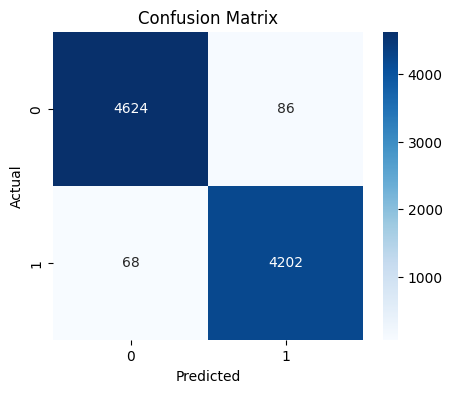

In [18]:
# Confusion Mtarix 

cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt='d',cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [20]:
# Saving Model 

import joblib
joblib.dump(model,"fake_news_model.pkl")
joblib.dump(vectorizer,"tfidf_vectorizer.pkl")
joblib.dump(cm, "confusion_matrix.pkl")
print("Saved Successfully")

Saved Successfully
